In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("customer_churn_dataset.csv")
df.head()

,customer_id,age,gender,tenure_months,contract_type,payment_method,internet_service,online_security,paperless_billing,monthly_charges,total_charges,support_tickets,churn
0,CUST_10001,56,Male,3.0,One-Year,Credit Card,DSL,No,No,62.62,143.25,1,0
1,CUST_10002,69,Male,8.0,Month-to-Month,Mailed Check,DSL,No,Yes,52.39,444.33,1,0
2,CUST_10003,46,Female,46.0,Month-to-Month,Bank Transfer,DSL,No,Yes,33.87,1559.11,0,0
3,CUST_10004,32,Male,10.0,One-Year,Bank Transfer,Fiber Optic,No,Yes,69.26,676.48,1,0
4,CUST_10005,60,Female,72.0,Two-Year,Bank Transfer,No,No,Yes,85.30,6137.51,0,0


In [3]:
df.shape

(5000, 13)

In [4]:
df.isnull().sum()

customer_id            0
age                    0
gender                 0
tenure_months        100
contract_type          0
payment_method         0
internet_service       0
online_security      120
paperless_billing      0
monthly_charges       80
total_charges          0
support_tickets        0
churn                  0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        5000 non-null   str    
 1   age                5000 non-null   int64  
 2   gender             5000 non-null   str    
 3   tenure_months      4900 non-null   float64
 4   contract_type      5000 non-null   str    
 5   payment_method     5000 non-null   str    
 6   internet_service   5000 non-null   str    
 7   online_security    4880 non-null   str    
 8   paperless_billing  5000 non-null   str    
 9   monthly_charges    4920 non-null   float64
 10  total_charges      5000 non-null   float64
 11  support_tickets    5000 non-null   int64  
 12  churn              5000 non-null   int64  
dtypes: float64(3), int64(3), str(7)
memory usage: 507.9 KB


In [6]:
df.describe()

,age,tenure_months,monthly_charges,total_charges,support_tickets,churn
count,5000.000000,4900.000000,4920.000000,5000.000000,5000.000000,5000.000000
mean,44.131200,22.728571,64.933421,1471.863910,2.003400,0.249400
std,15.213135,20.003342,19.836310,1417.077413,1.407475,0.432709
min,18.000000,1.000000,18.000000,0.000000,0.000000,0.000000
25%,31.000000,7.000000,51.227500,412.052500,1.000000,0.000000
50%,44.000000,16.000000,64.605000,1011.645000,2.000000,0.000000
75%,57.000000,33.000000,78.237500,2108.147500,3.000000,0.000000
max,70.000000,72.000000,120.000000,8081.260000,8.000000,1.000000


##Starting EDA

In [8]:
print(df["customer_id"].dtype)
print(df["customer_id"].isnull().sum())
print(df["customer_id"].nunique())
print(df["customer_id"].nunique == len(df))

str
0
5000
False


In [9]:
df["customer_id"].head()

0    CUST_10001
1    CUST_10002
2    CUST_10003
3    CUST_10004
4    CUST_10005
Name: customer_id, dtype: str

In [10]:
df = df.drop(columns = ["customer_id"])

In [11]:
df.shape

(5000, 12)

In [13]:
print(df["age"].dtype)
print(df["age"].isnull().sum())
print(df["age"].describe())
print(df["age"].skew())

int64
0
count    5000.000000
mean       44.131200
std        15.213135
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: age, dtype: float64
-0.013240796550649445


<Axes: ylabel='Frequency'>

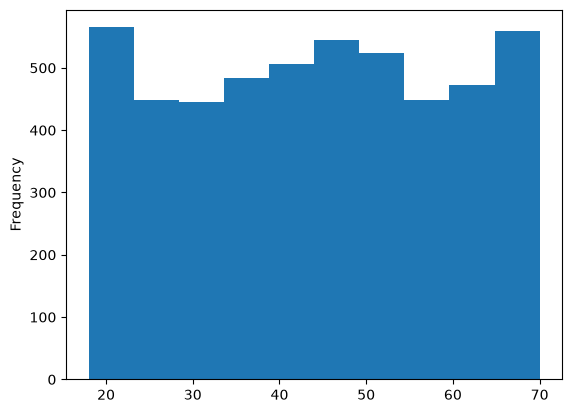

In [14]:
df["age"].plot(kind="hist")

<Axes: ylabel='Density'>

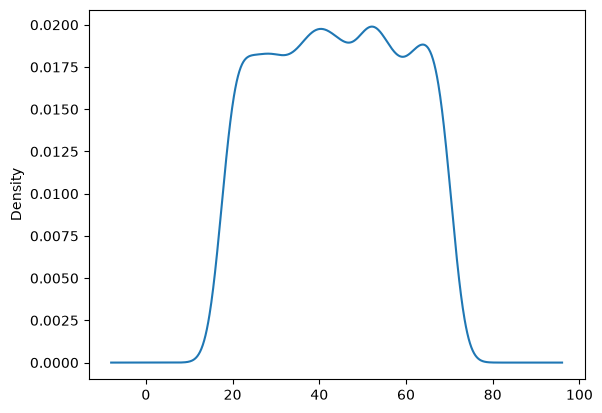

In [15]:
df["age"].plot(kind="kde")

<Axes: >

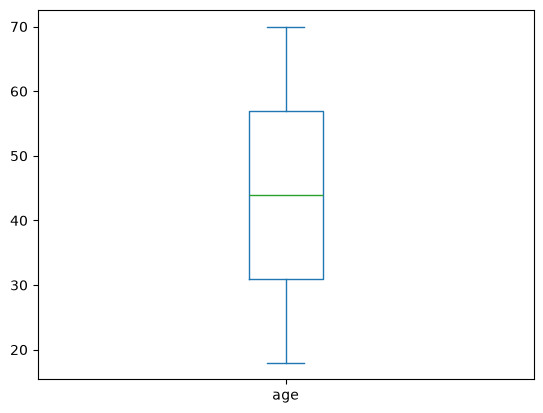

In [16]:
df["age"].plot(kind="box")

In [22]:
print(df.groupby('churn')['age'].agg(['count', 'mean', 'median', 'std']))

       count       mean  median        std
churn                                     
No      3753  44.248601    45.0  15.200605
Yes     1247  43.777867    43.0  15.251437


In [24]:
df['gender'].dtype

<StringDtype(storage='python', na_value=nan)>

In [25]:
df['gender'].isnull().sum()

np.int64(0)

In [26]:
df['gender'].value_counts()

gender
Male      2559
Female    2441
Name: count, dtype: int64

In [27]:
df['gender'].value_counts(normalize=True) * 100

gender
Male      51.18
Female    48.82
Name: proportion, dtype: float64

In [28]:
pd.crosstab(df['gender'], df['churn'], margins=True)

churn,No,Yes,All
gender,,,
Female,1822,619,2441
Male,1931,628,2559
All,3753,1247,5000


In [37]:
df['tenure_months'].dtype

dtype('float64')

In [38]:
df['tenure_months'].isnull().sum()

np.int64(100)

In [39]:
df['tenure_months'].describe()

count    4900.000000
mean       22.728571
std        20.003342
min         1.000000
25%         7.000000
50%        16.000000
75%        33.000000
max        72.000000
Name: tenure_months, dtype: float64

In [40]:
df['tenure_months'].skew()

np.float64(1.0641197924280423)

<Axes: ylabel='Density'>

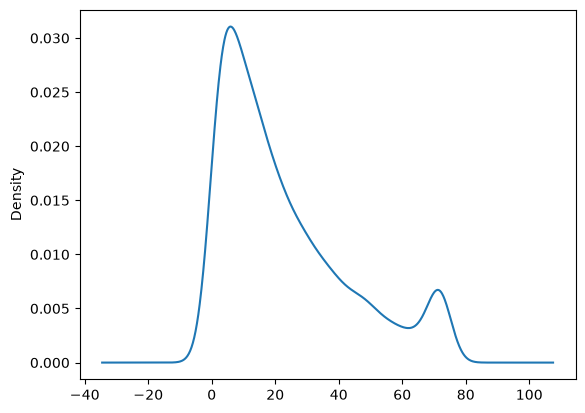

In [42]:
df['tenure_months'].plot(kind="kde")

<Axes: ylabel='Frequency'>

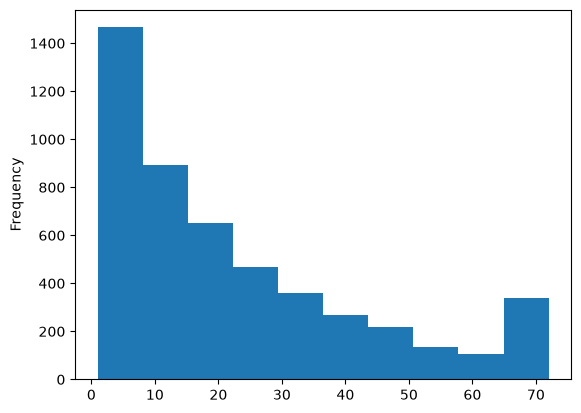

In [43]:
df['tenure_months'].plot(kind="hist")

In [44]:
tenure_median = df['tenure_months'].median()
df['tenure_months'] = df['tenure_months'].fillna(tenure_median)

In [45]:
df['tenure_months'].isnull().sum()

np.int64(0)

In [46]:
print("Data Type:", df['contract_type'].dtype)
print("Missing Count:", df['contract_type'].isnull().sum())

print(df['contract_type'].value_counts())

print((df['contract_type'].value_counts(normalize=True) * 100).round(2))

Data Type: str
Missing Count: 0
contract_type
Month-to-Month    2749
One-Year          1250
Two-Year          1001
Name: count, dtype: int64
contract_type
Month-to-Month    54.98
One-Year          25.00
Two-Year          20.02
Name: proportion, dtype: float64


In [ ]:
print(pd.crosstab(df['contract_type'], df['churn'], margins=True))

churn             No   Yes   All
contract_type                   
Month-to-Month  1738  1011  2749
One-Year        1098   152  1250
Two-Year         917    84  1001
All             3753  1247  5000


In [48]:
pd.crosstab(df['contract_type'], df['churn'], normalize='index') * 100

churn,No,Yes
contract_type,,
Month-to-Month,63.222990,36.777010
One-Year,87.840000,12.160000
Two-Year,91.608392,8.391608
